In [9]:
import os
import tarfile
import urllib.request

from country_name import country_name_rus

CL =[ "Afganistan","China","CAR", "Ethiopia",
      "India", "Iran","KNDR", "Libya", "Morocco", "Sudan",
      "Syria", "Turkey", "Argentina", "DRK_Congo", "Burkina_Faso",
      "Niger", "Mali", "Senegal", "Egipet", "Gvineya", "Venesuela",
      "Algeria", "Zimbabve", "Tunis", "Boliviya", "Braziliya",
      "Yuar", "Burundi", "Ruanda", "Mongoliya", 'Pakistan', 
     "Chili", 'Bangladesh', 'Benin', 'Gabon', 'Laos', 'Chad' , 
     'Keniya', 'Indoneziya','Iordaniya', 'Irak', 'Kambodzha', 'Kuba',
     'Tailand','Urugvay', 'Kamerun', 'Madagaskar', 'Mozambik', 'Yaponiya',
     'Mexico', 'Oae','Saudovskaya_araviya', 'Yemen', 'Pakistan', 'Laos', 'RK_Congo',
     'angola', 'belorussiya', 'litva', 'franciya', 'botsvana', 'vengriya',
     'italiya', 'germaniya' , 'palestina', 'izrail', 'tayvan', 'tanzaniya',
     'ispaniya',  'livan', 'oman','paragvay', 'peru', 'portugaliya', 'ssha','kolumbiya', 'uganda', 'nigeriya',
     'gana', 'Respublika-koreya', 'ekvatorialnaya-gvineya', 'kot-d-ivuar',  'namibiya', 'zambiya','vetnam',  'myanma', 'filippiny'
    ]

DIR_PATH= {}
DOWNLOAD_ROOT = "D:/ML/"
print(DOWNLOAD_ROOT)
#DATASET_PATH = os.path.join("datasets", "Countries")
DATASET_PATH = os.path.join("datasets", "Countries_V3")

for item in CL:
    DIR_PATH[country_name_rus[item]] = os.path.join(DATASET_PATH, item)
    
filenames = {}
for items in DIR_PATH.keys():   
    filenames[items] = [name for name in sorted(os.listdir(DIR_PATH[items])) ] 
    print(items)

D:/ML/
Афганистан
КНР
Центрально-Африканская Республика
Эфиопия 
Индия
Иран
КНДР
Ливия
Морокко
Судан
Сирия
Турция
Аргентина
ДРК (Конго)
Буркина-Фасо
Нигер
Мали
Сенегал
Египет
Гвинея
Венесуэла
Алжир
Зимбабве
Тунис
Боливия
Бразилия
ЮАР
Бурунди
Руанда
Монголия
Пакистан
Чили
Бангладеш
Бенин
Габон
Лаос
Чад
Кения
Индонезия
Иордания
Ирак
Камбоджа
Куба
Таиланд
Уругвай
Камерун
Мадагаскар
Мозамбик
Япония
Мексика
ОАЭ
Саудовская Аравия
Йемен
Республика Конго
Ангола
Беларусь
Литва
Франция
Ботсвана
Венгрия
Италия
Германия
Палестина
Израиль
КНР (Тайвань)
Танзания
Испания
Ливан
Оман
Парагвай
Перу
Португалия
США
Колумбия
Уганда
Нигерия
Гана
Южная Корея
Экваториальная Гвинея
Кот-д'Ивуар
Намибия
Замбия
Вьетнам
Мьянма
Филиппины


In [10]:
len(country_name_rus.keys())

85

In [11]:
stemming=False # Stemming control
if stemming:
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer("russian")

In [12]:
from stop_words_ru import ru_stopwords

In [13]:
load_from_DB = True # True - Загрузка БД из json файла
                        # False - Пересборка  json файла из отдельных текстовых файлов

In [14]:
from charset_normalizer import from_path
import string

def remove_chars_from_text(text, chars):
    # return "".join([ch for ch in text if ch not in chars])
    content = ''
    for ch in text:
        if ch not in chars:
            content = content + ''.join(ch)
        else:
            content = content + ''.join(' ')
    return content

import re

def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642" 
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, ' ', data)
spec_chars = string.punctuation + '\r' + '\n\xa0«»\t—…' 

def clean_text (post_text):    
    text_post = re.sub(r'https?:\/\/.*[\r\n]*', ' ', post_text, flags=re.MULTILINE)
    text_post = re.sub(r'#[^\s|\n]+', ' ', text_post)
    text_post = remove_emojis(text_post)
    text_post = text_post.replace('Тут была французская Западная Африка | Подписаться', ' ')
    text_post = text_post.replace('Африканская инициатива | Подписаться', ' ')
    text_post = text_post.replace('@sex_drugs_kahlo — латиноамериканское счастье [нет]', ' ')
    text_post = text_post.replace('Подписаться | Обратная связь', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('/Синьхуа/', ' ')
    text_post = text_post.replace('[Full Text]', ' ')
    return text_post

import time
import random
import codecs, json
from datetime import datetime

def json_cleaning_stemm (json_file_name):
    with open(json_file_name, encoding='utf-8') as json_file:
        article_data = json.load(json_file)
    result_data = {}   
    for item in article_data.keys():
        x_temp = []
        content = str(article_data[item]['text']).lower()
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token) > 2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    # print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
    
        content = ' '.join(filtered_words)   
        result_data [item] = {'text': content, 'country': article_data[item]['country']}
    try: 
        with codecs.open('{}_cleaning_stemm.json'.format(json_file_name[:-5]), 'w', encoding='utf-8') as f:
             f.write(json.dumps(result_data, sort_keys = True, ensure_ascii=False))    
    except Exception as ex:
        print(ex)
    return


In [15]:
import pandas as pd 
    #Reading the JSON File 
x_temp = []
y_temp = []

if load_from_DB:
    json_cleaning_stemm ('Country_DB_V4_29-01-2025.json')     
    df = pd.read_json('Country_DB_V4_29-01-2025_cleaning_stemm.json').T
else:
    for item in filenames.keys():
        post_temp=[]
        for names in filenames[item]:
            content = str(from_path(DIR_PATH[item]+"\\"+names).best())            
            content = clean_text(content)                
            x_temp.append(content)
            y_temp.append(item)
    try:
        article_data ={}
        for article_id in range(0, len(x_temp)):
            #print (article_id)
            article_data [article_id] = {'text': x_temp [article_id], 'country': y_temp [article_id]}
        time = datetime.now().strftime("%d-%m-%Y")
        with codecs.open('Country_DB_V4_{}.json'.format(time), 'w', encoding='utf-8') as f:
             f.write(json.dumps(article_data, sort_keys = True, ensure_ascii=False))
        json_cleaning_stemm ('Country_DB_V4_{}.json'.format(time))     
        df = pd.read_json('Country_DB_V4_{}_cleaning_stemm.json'.format(time)).T
    except Exception as ex:
        print(ex)

json_cleaning_stemm ('Country_DB_V4_checked_14-09-2025.json')
df_checked = pd.read_json('Country_DB_V4_checked_14-09-2025_cleaning_stemm.json').T
MergeJson = pd.concat([df, df_checked], axis=0)
        



In [16]:
df_checked

,country,text
0,Судан,судане сезонных наводнений пострадало тысяч че...
1,Судан,срыв американо суданских переговоров каире пер...
10,Турция,глава суверенного совета судана встретился пре...
100,Ирак,президент ирана масуд пезешкиан правительствен...
1000,Нигер,электростанция величество король мохаммед дека...
...,...,...
995,КНР,китайским банкам пообещали санкции времена сан...
996,Буркина-Фасо,буркина фасо школ открыты усилиям сил безопасн...
997,Буркина-Фасо,деревня тьебеле буркина фасо небольшая деревня...
998,Нигер,компания добыче полезных ископаемых подает суд...


In [17]:
df

,country,text
0,Афганистан,источники мест пишут вертолёт таджикистана отс...
1,Афганистан,присутствие запада афганистане минимальным под...
10,Афганистан,руководстве афганского талибана запрещенная те...
100,Афганистан,россия направила афганистан спецборт гуманитар...
1000,КНР,офиса казахско китайской компании cnpc актобем...
...,...,...
9995,Руанда,сми руанда обвинила конго причастности похищен...
9996,Руанда,африканский союз выразил беспокойство кризисом...
9997,Руанда,церковь англии раскритиковала планы правительс...
9998,Руанда,трасс подтвердила британия начнет отправлять н...


In [18]:
len(set(MergeJson["country"].tolist()))

85

In [19]:
from tabulate import tabulate
data =[]
for country in set(MergeJson["country"].tolist()):    
    data.append([country, MergeJson[MergeJson["country"]==country]['text'].count(), df[df["country"]==country]['text'].count(), df_checked[df_checked["country"]==country]['text'].count()])    
print(tabulate(data, headers=[' общая БД', 'старая БД', 'проверенная БД']))

                                      общая БД    старая БД    проверенная БД
---------------------------------  -----------  -----------  ----------------
Камерун                                    259          208                51
Куба                                       245          212                33
Португалия                                 214          203                11
Иордания                                   222          209                13
Сенегал                                    275          110               165
Нигер                                      168           64               104
Нигерия                                    281          185                96
Лаос                                       237          206                31
Индонезия                                  191           89               102
Венгрия                                    220          206                14
Намибия                                    190          171     

In [20]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

X_df = np.array(df['text'], dtype=object)
y_df = np.array(df['country'])

X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X_df, y_df, test_size=0.3, random_state=42)

In [21]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

X_df_checked = np.array(df_checked['text'], dtype=object)
y_df_checked = np.array(df_checked['country'])

X_train_df_checked, X_test_df_checked, y_train_df_checked, y_test_df_checked = train_test_split(X_df_checked, y_df_checked, test_size=0.3, random_state=42)

In [22]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
if load_from_DB:
    X = np.array(MergeJson['text'], dtype=object)
    y = np.array(MergeJson['country'])
else:
    X = np.array(x_temp, dtype=object)
    y = np.array(y_temp)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
len(X)

26728

In [24]:
len(y)

26728

In [25]:
MergeJson

,country,text
0,Афганистан,источники мест пишут вертолёт таджикистана отс...
1,Афганистан,присутствие запада афганистане минимальным под...
10,Афганистан,руководстве афганского талибана запрещенная те...
100,Афганистан,россия направила афганистан спецборт гуманитар...
1000,КНР,офиса казахско китайской компании cnpc актобем...
...,...,...
995,КНР,китайским банкам пообещали санкции времена сан...
996,Буркина-Фасо,буркина фасо школ открыты усилиям сил безопасн...
997,Буркина-Фасо,деревня тьебеле буркина фасо небольшая деревня...
998,Нигер,компания добыче полезных ископаемых подает суд...


In [26]:
from tabulate import tabulate
score_data = []

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
print (tfidf)
#tfidf= CountVectorizer(max_features=20000)
X_train_transformed_df = tfidf.fit_transform(X_train_df)
#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_df = DecisionTreeClassifier()
rf_df.fit(X_train_transformed_df, y_train_df)

y_pred_df = rf_df.predict_proba(X_train_transformed_df)[:, 1]
score_df = cross_val_score(rf_df, X_train_transformed_df, y_train_df, cv=3, verbose=3)
print(score_df.mean())
print(cross_val_score(rf_df, X_train_transformed_df, y_train_df, scoring='accuracy'))
print(cross_val_score(rf_df, X_train_transformed_df, y_train_df, scoring='f1_macro'))    

TfidfVectorizer(max_features=20000, min_df=6, ngram_range=(1, 5))
[CV] END ................................ score: (test=0.778) total time=  12.1s
[CV] END ................................ score: (test=0.765) total time=  12.0s
[CV] END ................................ score: (test=0.767) total time=  11.6s
0.7701202036450058
[0.77687627 0.77781535 0.76530267 0.76022996 0.76496449]
[0.75565561 0.73638751 0.73302191 0.73458067 0.73722958]


In [28]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed_df = tfidf.transform(X_test_df)

rf_df.fit(X_test_transformed_df, y_test_df)

y_pred_df = rf_df.predict(X_test_transformed_df)

score_data.append(['DecisionTreeClassifier (old BD)', "{:.2f}".format(100 * score_df.mean()),
              "{:.2f}".format(100 * precision_score(y_test_df, y_pred_df, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test_df, y_pred_df, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                    Precision (train), %     Precision(test), %    Recall(test), %
-------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                    77.01                   98.4              98.26


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
print (tfidf)
#tfidf= CountVectorizer(max_features=20000)
X_train_transformed = tfidf.fit_transform(X_train)
#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf = DecisionTreeClassifier()
rf.fit(X_train_transformed, y_train)

y_pred = rf.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf, X_train_transformed, y_train, scoring='f1_macro'))    

TfidfVectorizer(max_features=20000, min_df=6, ngram_range=(1, 5))
[CV] END ................................ score: (test=0.774) total time=  15.9s
[CV] END ................................ score: (test=0.779) total time=  15.9s
[CV] END ................................ score: (test=0.770) total time=  16.3s
0.7744401106064566
[0.77872795 0.77151256 0.77525387 0.77498664 0.77332264]
[0.75452231 0.73321844 0.73564273 0.74157241 0.73936026]


In [30]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf.fit(X_test_transformed, y_test)

y_pred = rf.predict(X_test_transformed)

score_data.append(['DecisionTreeClassifier (all BD)', "{:.2f}".format(100 * score.mean()),
              "{:.2f}".format(100 * precision_score(y_test, y_pred, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test, y_pred, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                    Precision (train), %     Precision(test), %    Recall(test), %
-------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                    77.01                  98.4               98.26
DecisionTreeClassifier (all BD)                    77.44                  98.68              98.58


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer





tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
print (tfidf)
#tfidf= CountVectorizer(max_features=20000)
X_train_transformed_df_checked = tfidf.fit_transform(X_train_df_checked)
#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_df_checked = DecisionTreeClassifier()
rf_df_checked.fit(X_train_transformed_df_checked, y_train_df_checked)

y_pred_df_checked = rf_df_checked.predict_proba(X_train_transformed_df_checked)[:, 1]
score = cross_val_score(rf_df_checked, X_train_transformed_df_checked, y_train_df_checked, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_df_checked, X_train_transformed_df_checked, y_train_df_checked, scoring='accuracy'))
print(cross_val_score(rf_df_checked, X_train_transformed_df_checked, y_train_df_checked, scoring='f1_macro'))    

TfidfVectorizer(max_features=20000, min_df=6, ngram_range=(1, 5))
[CV] END ................................ score: (test=0.753) total time=   1.9s
[CV] END ................................ score: (test=0.773) total time=   2.0s
[CV] END ................................ score: (test=0.761) total time=   2.0s
0.7624264233910248


D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


[0.77961783 0.7566879  0.78980892 0.77168367 0.7869898 ]


D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


[0.70207988 0.67428256 0.7015459  0.70113045 0.71161319]


In [32]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed_df_checked = tfidf.transform(X_test_df_checked)

rf_df_checked.fit(X_test_transformed_df_checked, y_test_df_checked)

y_pred_df_checked = rf_df_checked.predict(X_test_transformed_df_checked)

score_data.append(['DecisionTreeClassifier (checked BD)', "{:.2f}".format(100 * score.mean()),
              "{:.2f}".format(100 * precision_score(y_test_df_checked, y_pred_df_checked, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test_df_checked, y_pred_df_checked, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                        Precision (train), %     Precision(test), %    Recall(test), %
-----------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                        77.01                  98.4               98.26
DecisionTreeClassifier (all BD)                        77.44                  98.68              98.58
DecisionTreeClassifier (checked BD)                    76.24                 100                100


In [33]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_DecisionTreeClassifier_tfidf_V4_024_{}_lowRAM_nostamm_NEW.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf, tfidf], f_out)

In [34]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,5), min_df=6)
X_train_transformed_df = tfidf.fit_transform(X_train_df)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
#rf_RandomForest_df = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True, max_depth = 120, min_samples_split=12)
rf_RandomForest_df  = RandomForestClassifier(
    n_estimators=150,
    max_depth=40,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
    oob_score=True
)
rf_RandomForest_df.fit(X_train_transformed_df, y_train_df)

y_pred_df = rf_RandomForest_df.predict_proba(X_train_transformed_df)[:, 1]
score = cross_val_score(rf_RandomForest_df, X_train_transformed_df, y_train_df, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest_df, X_train_transformed_df, y_train_df, scoring='accuracy'))
print(cross_val_score(rf_RandomForest_df, X_train_transformed_df, y_train_df, scoring='f1_macro')) 
print(rf_RandomForest_df.oob_score_)

[CV] END ................................ score: (test=0.822) total time=   1.4s
[CV] END ................................ score: (test=0.814) total time=   1.3s
[CV] END ................................ score: (test=0.820) total time=   1.4s
0.8184770137467186
[0.82758621 0.82144065 0.81467704 0.80757525 0.82516064]
[0.79908401 0.79328901 0.78134257 0.76820618 0.79125199]
0.812119572568646


In [35]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed_df = tfidf.transform(X_test_df)

rf_RandomForest_df.fit(X_test_transformed_df, y_test_df)

y_pred_RandomForest_df = rf_RandomForest_df.predict(X_test_transformed_df)


score_data.append(['RandomForestClassifier (old BD)', "{:.2f}".format(100 * rf_RandomForest_df.oob_score_),
              "{:.2f}".format(100 * precision_score(y_test_df, y_pred_RandomForest_df, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test_df, y_pred_RandomForest_df, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                        Precision (train), %     Precision(test), %    Recall(test), %
-----------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                        77.01                  98.4               98.26
DecisionTreeClassifier (all BD)                        77.44                  98.68              98.58
DecisionTreeClassifier (checked BD)                    76.24                 100                100
RandomForestClassifier (old BD)                        79.64                  87.11              84.74


In [36]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,5), min_df=6)
X_train_transformed = tfidf.fit_transform(X_train)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
#rf_RandomForest = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True, max_depth = 120, min_samples_split=12)
rf_RandomForest  = RandomForestClassifier(
    n_estimators=150,
    max_depth=40,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
    oob_score=True
)
rf_RandomForest.fit(X_train_transformed, y_train)

y_pred = rf_RandomForest.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf_RandomForest, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='f1_macro')) 
print(rf_RandomForest.oob_score_)

[CV] END ................................ score: (test=0.821) total time=   1.7s
[CV] END ................................ score: (test=0.824) total time=   1.6s
[CV] END ................................ score: (test=0.827) total time=   1.7s
0.8242558590716241
[0.82683057 0.82175307 0.82522715 0.82683057 0.83079391]
[0.80979376 0.80338356 0.80333404 0.80767202 0.80767403]
0.8199262387086429


In [37]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf_RandomForest.fit(X_test_transformed, y_test)

y_pred_RandomForest = rf_RandomForest.predict(X_test_transformed)

score_data.append(['RandomForestClassifier (all BD)', "{:.2f}".format(100 * rf_RandomForest.oob_score_),
              "{:.2f}".format(100 * precision_score(y_test, y_pred_RandomForest, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test, y_pred_RandomForest, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                        Precision (train), %     Precision(test), %    Recall(test), %
-----------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                        77.01                  98.4               98.26
DecisionTreeClassifier (all BD)                        77.44                  98.68              98.58
DecisionTreeClassifier (checked BD)                    76.24                 100                100
RandomForestClassifier (old BD)                        79.64                  87.11              84.74
RandomForestClassifier (all BD)                        80.9                   87.57              85.65


In [38]:
new_text = ['Нигер последовал примеру Мали, разорвав связи с Украиной после того, как пресс-секретарь разведывательного агентства Министерства обороны Украины признал, что Украина оказывала поддержку повстанцам, которые убили малийских вооруженных сил и российских агентов 25-27 июля в Тинзауатене, на севере Мали, недалеко от границы с Алжиром.Посол Украины в Сенегале также выразил безоговорочную поддержку малийским повстанцам, что привело к вызову посла в МИД Сенегала.',
            'Еще новости афганской промышленности. В Кандагаре спустя 18 лет возобновила работу текстильная фабрика. Официальные лица говорят, что они отремонтировали оборудование на фабрике за шесть месяцев, сообщают афганское СМИ. По словам работников фабрики, с возобновлением работы фабрики созданы рабочие места. 69-летний Мохаммад, проработавший на текстильной фабрике в Кандагаре значительное время, рад вернуться на работу.',
           'Накопленное непонимание между Китаем и США не может быть решено лишь одним подобным изящным жестом. Страны расходятся по широкому кругу вопросов, санкционный механизм против Китая не ослаблен. Поэтому отправка панд – это скорее демонстрация миролюбивой позиции Китая в противовес США.',
            'В Алжире, как правило, на похоронах мужчины сидят около дома, хорошо, если есть сад или терраса, а женщины в доме, надеть платок женщина должна обязательно, даже если в обычной жизни она не покрывает голову. Если покойный жил в квартире, то прямо во дворе ставят стулья и шатры со столами для мужчин.Готовят либо нанятые кухарки, либо родственницы покойного. Пока составляла пост от подруги услышала,что в их семье часто еду приносят те, кто приходит в дом, а готовить должны невестки, а не дочери умершего. Мой муж сказал, что это совершенно необязательно, на похоронах его бабушки готовили только её дочери, это было их желание и никаких особых правил на счёт этого нет. Обязательного блюда на поминки в Алжире нет. Народ приходит помянутьот трех дней до недели, если у человека была большая семья и много знакомых!Кормят традиционными блюдами: суп-шорба, кус-кус/беркукес/тлитли с мясом и т.д.Могилу посещают каждое утро, в течении трех дней. Через 40 дней устанавливают небольшое надгробие, никаких памятников,вычурных элементов. На надгробии имя, фамилия, даты рождения и смерти, фотографий нет. Вроде бы написала всё, что знала. Задавайте вопросы в комментариях, если таковые имеются.',
            'Сегодня в Венесуэле проходят президентские выборы. Мой коллега Дмитрий Морозов рассуждает, как их итоги могут повлиять на дальнейший путь страны. Вот самое важное из его статьи.📍В выборах один тур, участвуют десять кандидатов, однако только двое имеют реальные шансы на победу: действующий президент Николас Мадуро и Эдмундо Гонсалес Уррутия, кандидат от Единой демократической платформы, объединяющей наиболее значимые оппозиционные партии.',
            'С возвращением Трампа в Белый дом «тропический Трамп» Жаир Болсонару осмелел и заявил, что, будь он сейчас президентом Бразилии, вышел бы из БРИКС. И попросился бы в Североамериканское соглашение о свободной торговле (NAFTA), к США, Канаде и Мексике. Он даже предложил переименовать его в Американское соглашение о свободной торговле (AFTA). Очень уж Болсонару раздражает, что теперь в БРИКС входят Куба и Боливия (правда, они не входят, а являются странами-партнерами. Но спасибо, хоть Испанию как страну БРИКС не перечислил). Только вот когда Болсонару действительно был президентом Бразилии, он из БРИКС не выходил. Хотя многие тогда и пророчили.',
            'Почему слова Трампа о присоединении Гренландии надо воспринимать всерьёз — статья Максима Сучкова @postamerica: • Присоединение территорий — обычный способ наращивания государствами мощи. Для лидеров — это ещё и возможность запомниться потомкам, войти в историю. Эгоцентрист-государственник Трамп желает и первого, и второго. Как политик-националист, он стремится укрепить американские позиции в «ближнем зарубежье» США. Как «политик на втором сроке», он хочет, чтобы каждое решение по этой части было стратегическим и долгосрочным, «оставляло наследие». А специфический образ мысли Трампа требует, чтобы это наследие обязательно было грандиозным. • В случае с заявлениями Трампа по поводу Гренландии партнёры Америки находятся в замешательстве: зачем забирать земли у союзников, да ещё в тот момент, когда они третий год подряд убеждают мир в том, что так нельзя и за это надо наказывать? Особенно негодуют французы и датчане, по иронии судьбы, некогда продавшие Соединённым Штатам свои заморские территории: французы — Луизиану в 1803 году (за $15 млн), датчане — Датскую Вест-Индию (современные Американские Виргинские Острова) в 1917 году (за $25 млн). • Трампа, очевидно, не сильно заботит эта реакция. Но ему, вероятно, хочется, чтобы процедура присоединения острова была оформлена красиво — с соблюдением внешних приличий и юридических правил. Провернуть всё это американцам вполне по силам: нация коммерсантов и юристов, по части способности покупать, продавать и обрамлять это изысканной правовой рамкой, равных себе не имеет. • Судя по всему, Трамп нацелен именно на этот сценарий: Трамп-младший слетал в Гренландию, где, по слухам, прощупывал местные лояльные Америке круги, выясняя их готовность организовать референдум о вхождении в состав США; республиканские законодатели в Конгрессе изучают варианты правового оформления этой инициативы; экономисты рассчитывают стоимость возможной сделки — она варьируется в диапазоне от $12,5 млрд до $77 млрд. Параллельно прорабатывается и вариант с долгосрочной арендой острова. • С середины XIX века Гренландия рассматривается США как ключ к контролю над Арктикой. Сегодня Арктика — одна из главных арен великодержавного соперничества. Традиционный инструментарий усиления в этом регионе самих американцев — виртуозно использовать нормотворчество, регламентирующее пользование Арктикой, и стремиться увеличивать площади континентального шельфа. Это они делали задолго до Трампа. • Сам же Трамп убеждён: в то время как конкуренты США укреплялись, Байден и его команда на протяжении четырёх лет только и делали, что бездумно расточали ресурсы страны. Пришла пора собирать камни. Читать статью для @profilejournal'
           ]
x_temp = []
for post_temp in new_text:
        content = str(post_temp).lower()  
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token)>2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    #print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
                      
        content = ' '.join(filtered_words)  
        #if ngram_replace:
        #    for item in vocabl:
        #        if item.replace('_', ' ') in vocabl:
         #           content.replace(item.replace('_', ' '), item)
                    #print(item)                
        x_temp.append(content)
# Очищаем текст (ваша функция clean_text)
x_temp = [clean_text(t) for t in new_text]

# Векторизуем через обученный tfidf
X_t = tfidf.transform(x_temp)

# Предсказываем
predictions = rf_RandomForest.predict(X_t)
probabilities = rf_RandomForest.predict_proba(X_t)
print (predictions)
print (probabilities)

['Сенегал' 'Индонезия' 'КНР' 'Алжир' 'Венесуэла' 'Бразилия' 'США']
[[0.01232994 0.00455246 0.00492277 0.00378621 0.00326556 0.01266862
  0.02035814 0.00381472 0.00455335 0.00497973 0.00467016 0.00412184
  0.00409994 0.00432512 0.00454012 0.00302221 0.01231102 0.00378604
  0.00538474 0.00411675 0.00528287 0.00444342 0.00410007 0.00407539
  0.00511435 0.00400726 0.00391764 0.00285305 0.0048985  0.00789308
  0.00502291 0.00253445 0.00453624 0.00573599 0.00166351 0.00316544
  0.00821974 0.00455142 0.00415298 0.00729705 0.00530586 0.00670204
  0.00370055 0.00484481 0.00496905 0.00356709 0.13863193 0.00671145
  0.00626128 0.00258015 0.00827603 0.00527345 0.00603831 0.08856911
  0.01831686 0.00499656 0.00477955 0.00813042 0.00463533 0.00464901
  0.00695514 0.00503201 0.00695374 0.00521442 0.00583122 0.00457606
  0.31143443 0.00517589 0.00465807 0.00562142 0.00596838 0.00444095
  0.00476855 0.00525383 0.00473818 0.0034398  0.00587126 0.00597049
  0.01506166 0.00371616 0.00304511 0.00554115 0.0

In [39]:
probabilities = rf_RandomForest.predict_proba(X_t)
for i, prob in enumerate(rf_RandomForest.predict(X_t)):
    print(f"Sample {i}")
    for ix , probx in enumerate(rf_RandomForest.classes_):
        if probabilities[i][ix]>0.02:
            print(f" Class {probx}, Probability = {probabilities[i][ix]:.2f}")

Sample 0
 Class Бенин, Probability = 0.02
 Class Мали, Probability = 0.14
 Class Нигер, Probability = 0.09
 Class Сенегал, Probability = 0.31
Sample 1
Sample 2
 Class КНР, Probability = 0.08
Sample 3
 Class Алжир, Probability = 0.06
Sample 4
 Class Бразилия, Probability = 0.02
 Class Венесуэла, Probability = 0.32
 Class Колумбия, Probability = 0.02
 Class Парагвай, Probability = 0.04
Sample 5
 Class Боливия, Probability = 0.02
 Class Бразилия, Probability = 0.19
 Class Куба, Probability = 0.05
 Class США, Probability = 0.03
Sample 6
 Class США, Probability = 0.04


In [40]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_rf_tfidf_V4_024_{}_lowRAM_nostamm.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf_RandomForest, tfidf], f_out)

In [41]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,5), min_df=6)
X_train_transformed_df_checked = tfidf.fit_transform(X_train_df_checked)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_RandomForest_df_checked = RandomForestClassifier(
    n_estimators=150,
    max_depth=40,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
    oob_score=True
)
rf_RandomForest_df_checked.fit(X_train_transformed_df_checked, y_train_df_checked)

y_pred_df_checked = rf_RandomForest_df_checked.predict_proba(X_train_transformed_df_checked)[:, 1]
score = cross_val_score(rf_RandomForest_df_checked, X_train_transformed_df_checked, y_train_df_checked, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest_df_checked, X_train_transformed_df_checked, y_train_df_checked, scoring='accuracy'))
print(cross_val_score(rf_RandomForest_df_checked, X_train_transformed_df_checked, y_train_df_checked, scoring='f1_macro')) 
print(rf_RandomForest_df_checked.oob_score_)

[CV] END ................................ score: (test=0.775) total time=   0.3s
[CV] END ................................ score: (test=0.764) total time=   0.3s
[CV] END ................................ score: (test=0.783) total time=   0.3s
0.7741548097868686


D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


[0.77707006 0.76687898 0.79235669 0.79591837 0.79591837]


D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


[0.73058009 0.72284581 0.75079835 0.75855779 0.74991232]
0.7593678307417793


In [42]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed_df_checked = tfidf.transform(X_test_df_checked)

rf_RandomForest_df_checked.fit(X_test_transformed_df_checked, y_test_df_checked)

y_pred_RandomForest_df_checked = rf_RandomForest_df_checked.predict(X_test_transformed_df_checked)


score_data.append(['RandomForestClassifier (checked BD)', "{:.2f}".format(100 * rf_RandomForest_df_checked.oob_score_),
              "{:.2f}".format(100 * precision_score(y_test_df_checked, y_pred_RandomForest_df_checked, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test_df_checked, y_pred_RandomForest_df_checked, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                        Precision (train), %     Precision(test), %    Recall(test), %
-----------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                        77.01                  98.4               98.26
DecisionTreeClassifier (all BD)                        77.44                  98.68              98.58
DecisionTreeClassifier (checked BD)                    76.24                 100                100
RandomForestClassifier (old BD)                        79.64                  87.11              84.74
RandomForestClassifier (all BD)                        80.9                   87.57              85.65
RandomForestClassifier (checked BD)                    68.37                  88.75              80.32


In [43]:
print('Итоговая сводка:')
from tabulate import tabulate
data =[]
score = []
for country in set(MergeJson["country"].tolist()):    
    data.append([country, MergeJson[MergeJson["country"]==country]['text'].count(), df[df["country"]==country]['text'].count(), df_checked[df_checked["country"]==country]['text'].count()])    
print(tabulate(data, headers=[' общая БД', 'старая БД', 'проверенная БД']))
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

Итоговая сводка:
                                      общая БД    старая БД    проверенная БД
---------------------------------  -----------  -----------  ----------------
Камерун                                    259          208                51
Куба                                       245          212                33
Португалия                                 214          203                11
Иордания                                   222          209                13
Сенегал                                    275          110               165
Нигер                                      168           64               104
Нигерия                                    281          185                96
Лаос                                       237          206                31
Индонезия                                  191           89               102
Венгрия                                    220          206                14
Намибия                                    190 

In [44]:
impoгtances = rf_RandomForest_df_checked.feature_importances_
feature_imp_df = pd.DataFrame({'Word': tfidf.get_feature_names_out(), 'Importance': impoгtances}).sort_values('Importance', ascending=False) 
print(feature_imp_df[:50])

                  Word  Importance
703            буркина    0.010941
3728            мадуро    0.010423
3499               кот    0.010390
4589           нигерии    0.010334
2652          зимбабве    0.009847
3361             конго    0.009589
440          бангладеш    0.009073
8686          танзании    0.009005
5425          парагвая    0.008388
9304          филиппин    0.008267
3646             ливии    0.008125
9276              фасо    0.007654
3761           марокко    0.007542
3131          камбоджи    0.007535
3075            италии    0.007474
8942            турции    0.007310
1467          германии    0.006977
3316          колумбии    0.006959
553                бин    0.006883
514             бенина    0.006707
3740              мали    0.006670
5429            париже    0.006633
704       буркина фасо    0.006615
9007            уганды    0.006587
9907               юар    0.006416
621            боливии    0.006222
297             анголы    0.006196
9583              ча

In [45]:
with open('./datasets/feature_importances_nostamm.txt', "w", encoding="utf-8") as some_file:
    some_file.write(feature_imp_df.to_string())

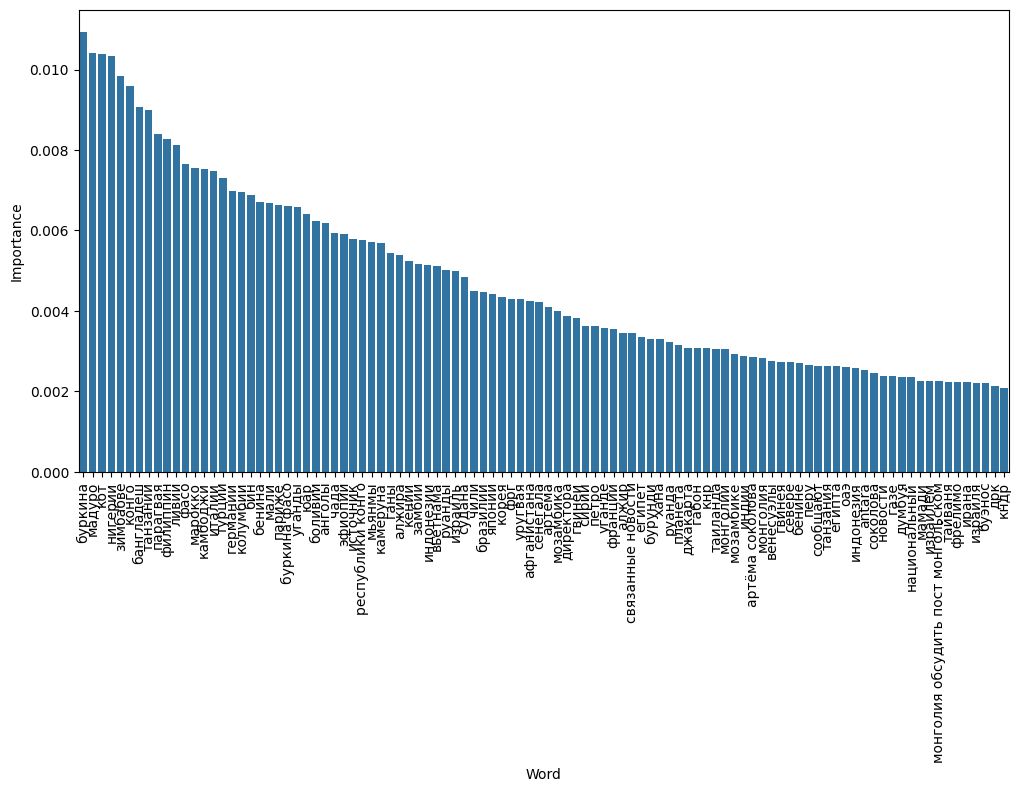

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #pip install seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Word", y="Importance", data=feature_imp_df[:100])

ax.tick_params(axis='x', labelrotation=90)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# ax.set_xticks(ticks=ax.get_xticks(), labels=ax.get_xticklabels(), rotation=45, ha='right')
plt.show()


In [47]:
new_text = ['Нигер последовал примеру Мали, разорвав связи с Украиной после того, как пресс-секретарь разведывательного агентства Министерства обороны Украины признал, что Украина оказывала поддержку повстанцам, которые убили малийских вооруженных сил и российских агентов 25-27 июля в Тинзауатене, на севере Мали, недалеко от границы с Алжиром.Посол Украины в Сенегале также выразил безоговорочную поддержку малийским повстанцам, что привело к вызову посла в МИД Сенегала.',
            'Еще новости афганской промышленности. В Кандагаре спустя 18 лет возобновила работу текстильная фабрика. Официальные лица говорят, что они отремонтировали оборудование на фабрике за шесть месяцев, сообщают афганское СМИ. По словам работников фабрики, с возобновлением работы фабрики созданы рабочие места. 69-летний Мохаммад, проработавший на текстильной фабрике в Кандагаре значительное время, рад вернуться на работу.',
           'Накопленное непонимание между Китаем и США не может быть решено лишь одним подобным изящным жестом. Страны расходятся по широкому кругу вопросов, санкционный механизм против Китая не ослаблен. Поэтому отправка панд – это скорее демонстрация миролюбивой позиции Китая в противовес США.',
            'В Алжире, как правило, на похоронах мужчины сидят около дома, хорошо, если есть сад или терраса, а женщины в доме, надеть платок женщина должна обязательно, даже если в обычной жизни она не покрывает голову. Если покойный жил в квартире, то прямо во дворе ставят стулья и шатры со столами для мужчин.Готовят либо нанятые кухарки, либо родственницы покойного. Пока составляла пост от подруги услышала,что в их семье часто еду приносят те, кто приходит в дом, а готовить должны невестки, а не дочери умершего. Мой муж сказал, что это совершенно необязательно, на похоронах его бабушки готовили только её дочери, это было их желание и никаких особых правил на счёт этого нет. Обязательного блюда на поминки в Алжире нет. Народ приходит помянутьот трех дней до недели, если у человека была большая семья и много знакомых!Кормят традиционными блюдами: суп-шорба, кус-кус/беркукес/тлитли с мясом и т.д.Могилу посещают каждое утро, в течении трех дней. Через 40 дней устанавливают небольшое надгробие, никаких памятников,вычурных элементов. На надгробии имя, фамилия, даты рождения и смерти, фотографий нет. Вроде бы написала всё, что знала. Задавайте вопросы в комментариях, если таковые имеются.',
            'Сегодня в Венесуэле проходят президентские выборы. Мой коллега Дмитрий Морозов рассуждает, как их итоги могут повлиять на дальнейший путь страны. Вот самое важное из его статьи.📍В выборах один тур, участвуют десять кандидатов, однако только двое имеют реальные шансы на победу: действующий президент Николас Мадуро и Эдмундо Гонсалес Уррутия, кандидат от Единой демократической платформы, объединяющей наиболее значимые оппозиционные партии.',
            'С возвращением Трампа в Белый дом «тропический Трамп» Жаир Болсонару осмелел и заявил, что, будь он сейчас президентом Бразилии, вышел бы из БРИКС. И попросился бы в Североамериканское соглашение о свободной торговле (NAFTA), к США, Канаде и Мексике. Он даже предложил переименовать его в Американское соглашение о свободной торговле (AFTA). Очень уж Болсонару раздражает, что теперь в БРИКС входят Куба и Боливия (правда, они не входят, а являются странами-партнерами. Но спасибо, хоть Испанию как страну БРИКС не перечислил). Только вот когда Болсонару действительно был президентом Бразилии, он из БРИКС не выходил. Хотя многие тогда и пророчили.',
            'Почему слова Трампа о присоединении Гренландии надо воспринимать всерьёз — статья Максима Сучкова @postamerica: • Присоединение территорий — обычный способ наращивания государствами мощи. Для лидеров — это ещё и возможность запомниться потомкам, войти в историю. Эгоцентрист-государственник Трамп желает и первого, и второго. Как политик-националист, он стремится укрепить американские позиции в «ближнем зарубежье» США. Как «политик на втором сроке», он хочет, чтобы каждое решение по этой части было стратегическим и долгосрочным, «оставляло наследие». А специфический образ мысли Трампа требует, чтобы это наследие обязательно было грандиозным. • В случае с заявлениями Трампа по поводу Гренландии партнёры Америки находятся в замешательстве: зачем забирать земли у союзников, да ещё в тот момент, когда они третий год подряд убеждают мир в том, что так нельзя и за это надо наказывать? Особенно негодуют французы и датчане, по иронии судьбы, некогда продавшие Соединённым Штатам свои заморские территории: французы — Луизиану в 1803 году (за $15 млн), датчане — Датскую Вест-Индию (современные Американские Виргинские Острова) в 1917 году (за $25 млн). • Трампа, очевидно, не сильно заботит эта реакция. Но ему, вероятно, хочется, чтобы процедура присоединения острова была оформлена красиво — с соблюдением внешних приличий и юридических правил. Провернуть всё это американцам вполне по силам: нация коммерсантов и юристов, по части способности покупать, продавать и обрамлять это изысканной правовой рамкой, равных себе не имеет. • Судя по всему, Трамп нацелен именно на этот сценарий: Трамп-младший слетал в Гренландию, где, по слухам, прощупывал местные лояльные Америке круги, выясняя их готовность организовать референдум о вхождении в состав США; республиканские законодатели в Конгрессе изучают варианты правового оформления этой инициативы; экономисты рассчитывают стоимость возможной сделки — она варьируется в диапазоне от $12,5 млрд до $77 млрд. Параллельно прорабатывается и вариант с долгосрочной арендой острова. • С середины XIX века Гренландия рассматривается США как ключ к контролю над Арктикой. Сегодня Арктика — одна из главных арен великодержавного соперничества. Традиционный инструментарий усиления в этом регионе самих американцев — виртуозно использовать нормотворчество, регламентирующее пользование Арктикой, и стремиться увеличивать площади континентального шельфа. Это они делали задолго до Трампа. • Сам же Трамп убеждён: в то время как конкуренты США укреплялись, Байден и его команда на протяжении четырёх лет только и делали, что бездумно расточали ресурсы страны. Пришла пора собирать камни. Читать статью для @profilejournal'
           ]
x_temp = []
for post_temp in new_text:
        content = str(post_temp).lower()  
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token)>2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    #print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
                      
        content = ' '.join(filtered_words)  
        #if ngram_replace:
        #    for item in vocabl:
        #        if item.replace('_', ' ') in vocabl:
         #           content.replace(item.replace('_', ' '), item)
                    #print(item)                
        x_temp.append(content)

# Очищаем текст (ваша функция clean_text)
x_temp = [clean_text(t) for t in new_text]

# Векторизуем через обученный tfidf
X_t = tfidf.transform(x_temp)

# Предсказываем
predictions_df_checked = rf_RandomForest_df_checked.predict(X_t)
probabilities_df_checked = rf_RandomForest_df_checked.predict_proba(X_t)
print (predictions_df_checked)
print (probabilities_df_checked)



['Мали' 'Израиль' 'КНР' 'Алжир' 'Венесуэла' 'Бразилия' 'США']
[[0.01490515 0.00712551 0.00839661 0.00835331 0.01283313 0.02672978
  0.0078051  0.00848543 0.00418405 0.00836818 0.00742305 0.00402183
  0.0017075  0.00614937 0.00562561 0.01031357 0.00825074 0.0072174
  0.00335842 0.0061103  0.007323   0.0043187  0.01120813 0.00764519
  0.00947033 0.00300282 0.00427516 0.00632711 0.00810691 0.00904357
  0.00612082 0.00072709 0.00968586 0.01007582 0.00248173 0.00331737
  0.00781776 0.00838389 0.00672292 0.00515754 0.00954593 0.00943885
  0.00641951 0.00794849 0.00572572 0.00375373 0.17355346 0.00943406
  0.00619431 0.00268679 0.01071771 0.00777906 0.00151169 0.0370887
  0.00746404 0.00788624 0.00398456 0.00865954 0.00387435 0.0054656
  0.00678088 0.01010065 0.00477018 0.00580154 0.00921396 0.00325355
  0.17132774 0.00807215 0.0089632  0.0091218  0.00622093 0.01224414
  0.00728295 0.0081737  0.01022583 0.00504261 0.0030471  0.00980447
  0.01312841 0.005291   0.02063831 0.00909959 0.00766026 

In [48]:
for i, prob in enumerate(rf_RandomForest_df_checked.predict(X_t)):
    print(f"Sample {i}")
    for ix , probx in enumerate(rf_RandomForest_df_checked.classes_):
        if predictions_df_checked[i][ix]>0.02:
            print(f" Class {probx}, Probability = {predictions_df_checked[i][ix]:.2f}")

Sample 0


TypeError: '>' not supported between instances of 'str' and 'float'

In [ ]:
rf_RandomForest.classes_

In [ ]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_rf_tfidf_V4_024_{}_lowRAM_nostamm_NEW.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf_RandomForest_df_checked, tfidf], f_out)